## Purpose
This notebook is to calculate stocks with a 14-day RSI of 25 and identify the first 25 highest RSI stocks.
This stock is considered oversold, meaning it could be undervalued and could bounce back.

In [181]:
%matplotlib inline
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, current_date, date_sub
import configparser
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.sql import DataFrame
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import DoubleType

In [182]:
config = configparser.ConfigParser()
config.read(os.path.join(os.path.dirname(os.path.abspath("__file__")), '../conf/config.ini'))
url = 'jdbc:mysql://localhost/{}'.format(config.get('mysql', 'database'))
driver = config.get('mysql', 'driver')
tablename = "stocksinfp"
username = config.get('mysql', 'username')
password = config.get('mysql', 'password')
print("url : ", url)
print("Driver : ", driver)
print("MySQL User : ", username)

url :  jdbc:mysql://localhost/stocksdb
Driver :  com.mysql.cj.jdbc.Driver
MySQL User :  quizadmin


In [183]:
spark = SparkSession.builder.appName("Best25Stocks") \
.master("local[*]") \
.config("spark.jars",
                "/Users/gaurav/.m2/repository/com/mysql/mysql-connector-j/8.0.33/mysql-connector-j-8.0.33.jar") \
.getOrCreate()

In [184]:
stock_df = spark.read.format("jdbc").options(url=url, driver=driver, user=username, password=password, dbtable=tablename).load()
#spark.sparkContext.stop()

In [185]:
# Filter for records in the last 1 year
one_year_ago = date_sub(current_date(), 180)
filtered_df = stock_df.filter(col("Date") >= one_year_ago)
#filtered_df = filtered_df.filter(col("Symbol") == 'GOOG')
# Show the result
filtered_df.printSchema()
filtered_df.show(2, truncate=False)

root
 |-- Date: date (nullable = true)
 |-- Open: string (nullable = true)
 |-- High: string (nullable = true)
 |-- Low: string (nullable = true)
 |-- Close: string (nullable = true)
 |-- Adj Close: string (nullable = true)
 |-- Volume: string (nullable = true)
 |-- symbol: string (nullable = true)
 |-- price_change: double (nullable = true)

+----------+------------------+------------------+------------------+------------------+------------------+--------+------+-----------------+
|Date      |Open              |High              |Low               |Close             |Adj Close         |Volume  |symbol|price_change     |
+----------+------------------+------------------+------------------+------------------+------------------+--------+------+-----------------+
|2024-08-15|224.60000610351562|225.35000610351562|222.75999450683594|224.72000122070312|224.72000122070312|46414000|AAPL  |3.0              |
|2024-08-15|194.49000549316406|194.99000549316406|191.2899932861328 |193.39999389648438

In [186]:
# Function to calculate the 14-day RSI
def calculate_rsi(df, window_size=14):
    # Calculate price change
    #df = df.withColumn('price_change', F.col('Close') - F.lag('Close', 1).over(Window.partitionBy('symbol').orderBy('Date')))
    
    # Step 1: Create a window partitioned by symbol and ordered by date (descending to keep last 14)
    latest_14_days_window = Window.partitionBy("symbol").orderBy(F.desc("Date"))
    
    # Step 2: Rank rows based on the latest date and filter only last 14 per stock
    df = df.withColumn("rank", F.row_number().over(latest_14_days_window))
    df = df.filter(F.col("rank") <= 14).drop("rank")  # Keep only last 14 rows per symbol
    
    
    # Calculate gain and loss
    df = df.withColumn('gain', F.when(F.col('price_change') > 0, F.col('price_change')).otherwise(0))
    df = df.withColumn('loss', F.when(F.col('price_change') < 0, -F.col('price_change')).otherwise(0))

    # Calculate rolling average gain and loss
    window_spec = Window.partitionBy('symbol').orderBy('Date').rowsBetween(-window_size + 1, 0)
    
    df = df.withColumn('avg_gain', F.avg('gain').over(window_spec))
    df = df.withColumn('avg_loss', F.avg('loss').over(window_spec))

    # Calculate RS (Relative Strength) and RSI
    df = df.withColumn('rs', F.col('avg_gain') / F.col('avg_loss'))
    df = df.withColumn('rsi', 100 - (100 / (1 + F.col('rs'))))
    # Remove rows where RSI is null
    df = df.filter(F.col("rsi").isNotNull()) #& (F.col("rsi") != 0 )

    return df

In [187]:
# Apply RSI calculation
df_rsi = calculate_rsi(filtered_df)

In [188]:
# Show the result
#df_rsi.select('symbol', 'Date', 'rs','avg_gain','avg_loss','rsi').show(15)

In [189]:
# Step 8: Select only the latest RSI value per stock
latest_rsi_df = df_rsi.withColumn(
    "rank", F.row_number().over(Window.partitionBy("symbol").orderBy(F.desc("Date")))
).filter(F.col("rank") == 1).drop("rank")

# Filter the stocks with RSI <= 25
low_rsi_stocks = latest_rsi_df.filter(latest_rsi_df['rsi'] <= 25)

# Sort the stocks by RSI value in ascending order
low_rsi_sorted = low_rsi_stocks.orderBy('rsi', ascending=True)

# Select the top 25 stocks with the lowest RSI
top_25_low_rsi_stocks = low_rsi_sorted.limit(25)

# Convert Spark DataFrame to Pandas DataFrame for plotting
top_25_low_rsi_pandas = top_25_low_rsi_stocks.toPandas()

#top_25_low_rsi_pandas

In [190]:
# Step 1: Get the latest price for each stock
latest_price_df = filtered_df.withColumn(
    "rank", F.row_number().over(Window.partitionBy("symbol").orderBy(F.desc("Date")))
).filter(F.col("rank") == 1).select("symbol", "Close").withColumnRenamed("Close", "latest_price")

# Step 2: Get the price 14 days ago for each stock
price_14_days_ago_df = filtered_df.withColumn(
    "rank", F.row_number().over(Window.partitionBy("symbol").orderBy(F.desc("Date")))
).filter(F.col("rank") == 14).select("symbol", "Close").withColumnRenamed("Close", "price_14_days_ago")

# Step 3: Join both datasets
price_drop_df = latest_price_df.join(price_14_days_ago_df, on="symbol", how="inner")

# Step 4: Calculate the percentage drop
price_drop_df = price_drop_df.withColumn(
    "drop_percent", ((F.col("price_14_days_ago") - F.col("latest_price")) / F.col("price_14_days_ago")) * 100
)
price_drop_df.show()

+------+------------------+------------------+-------------------+
|symbol|      latest_price| price_14_days_ago|       drop_percent|
+------+------------------+------------------+-------------------+
|  AAPL| 227.6300048828125|222.63999938964844| -2.241288855032251|
|  ABBV|190.60000610351562|172.61000061035156|-10.422342523348087|
|   ACB|  6.03000020980835|3.9000000953674316| -54.61538621424684|
|  ACHR| 9.020000457763672| 9.699999809265137|  7.010302730644908|
|  AFRM| 75.22000122070312|  56.7599983215332| -32.52290952265003|
|    AI| 33.47999954223633|32.810001373291016|-2.0420546812007285|
|   ALB| 77.37000274658203| 94.05000305175781|   17.7352469579362|
|  ALEC|              1.75|1.7300000190734863|-1.1560682489023788|
|  ALGM|24.280000686645508|              25.0| 2.8799972534179688|
|  ALGT| 90.48999786376953|105.30000305175781|  14.06458191716173|
|   ALT| 6.659999847412109| 6.829999923706055|  2.489020178520015|
|  AMBA| 75.72000122070312|  82.6500015258789|  8.384755205365

In [191]:
# Step 5: Filter for the 25 stocks with the lowest RSI
top_25_low_rsi_stocks_v2 = top_25_low_rsi_stocks.select("symbol").join(price_drop_df, on="symbol", how="inner")

top_25_low_rsi_stocks_v2.show(25)

+------+--------------------+--------------------+------------------+
|symbol|        latest_price|   price_14_days_ago|      drop_percent|
+------+--------------------+--------------------+------------------+
|   ALB|   77.37000274658203|   94.05000305175781|  17.7352469579362|
|   AMC|  3.0999999046325684|  3.4800000190734863|  10.9195434585684|
|  AMTX|  2.0399999618530273|   2.700000047683716|24.444447191654362|
|  ANVS|   2.940000057220459|    5.21999979019165|43.678157559609446|
|  CELH|   22.40999984741211|  26.809999465942383|16.411785550834256|
|   CXW|   18.43000030517578|  22.940000534057617|19.659983103252827|
|  EBET|0.000399999989895...|0.000199999994947...|            -100.0|
|   GME|  24.729999542236328|  27.469999313354492| 9.974517071742765|
|  MANH|  200.89999389648438|   282.0799865722656|28.779068540895537|
|  MARA|  16.770000457763672|  19.559999465942383|14.263798999773089|
|    ME|  2.5299999713897705|  3.5799999237060547| 29.32960823164803|
|   OMI|   8.6499996

In [192]:
# Step 6: Convert to Pandas for visualization
top_25_low_rsi_pandas_v2 = top_25_low_rsi_stocks_v2.toPandas()
# Convert price columns to numeric
top_25_low_rsi_pandas_v2["latest_price"] = pd.to_numeric(top_25_low_rsi_pandas_v2["latest_price"])
top_25_low_rsi_pandas_v2["price_14_days_ago"] = pd.to_numeric(top_25_low_rsi_pandas_v2["price_14_days_ago"])

top_25_low_rsi_pandas_v2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symbol             17 non-null     object 
 1   latest_price       17 non-null     float64
 2   price_14_days_ago  17 non-null     float64
 3   drop_percent       17 non-null     float64
dtypes: float64(3), object(1)
memory usage: 672.0+ bytes


In [193]:


# Step 6: Melt the dataframe for Seaborn catplot
# Melt DataFrame for Seaborn
df_melted = top_25_low_rsi_pandas_v2.melt(id_vars=["symbol", "drop_percent"], 
                                       value_vars=["price_14_days_ago","latest_price"], 
                                       var_name="Price Type", 
                                       value_name="Price")
df_melted

,symbol,drop_percent,Price Type,Price
0,ALB,17.735247,price_14_days_ago,94.050003
1,AMC,10.919543,price_14_days_ago,3.480000
2,AMTX,24.444447,price_14_days_ago,2.700000
3,ANVS,43.678158,price_14_days_ago,5.220000
4,CELH,16.411786,price_14_days_ago,26.809999
5,CXW,19.659983,price_14_days_ago,22.940001
6,EBET,-100.000000,price_14_days_ago,0.000200
7,GME,9.974517,price_14_days_ago,27.469999
8,MANH,28.779069,price_14_days_ago,282.079987
9,MARA,14.263799,price_14_days_ago,19.559999


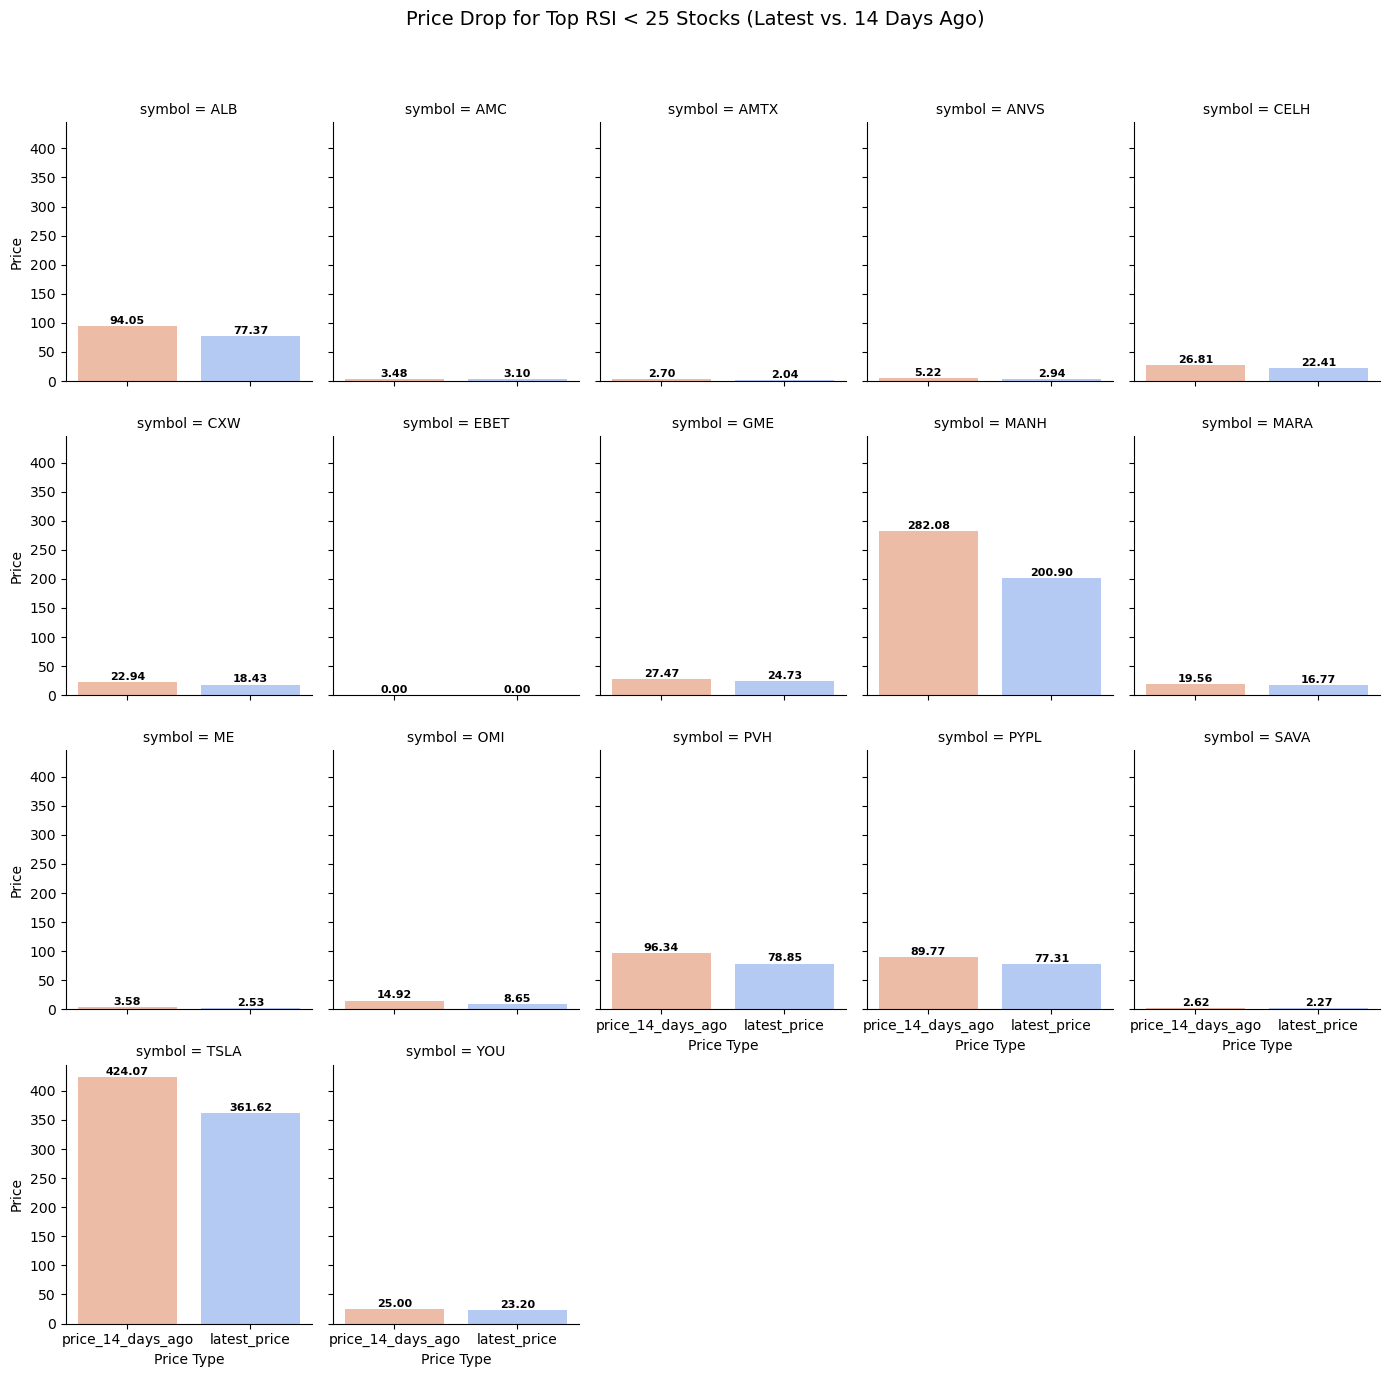

In [194]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assign color based on drop percent
df_melted["color"] = df_melted.apply(lambda row: "red" if row["drop_percent"] < 0 else "green", axis=1)

# Plot using catplot
g = sns.catplot(x="Price Type", y="Price", col="symbol", col_wrap=5, 
                data=df_melted, kind="bar", height=3.5, aspect=0.8, 
                hue="Price Type", palette="coolwarm_r", legend=False)

# Display actual values on top of bars
for ax in g.axes.flat:
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width() / 2, height + 0.5, 
                f'{height:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Set title
g.fig.suptitle('Price Drop for Top RSI < 25 Stocks (Latest vs. 14 Days Ago)', fontsize=14)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.9)

# Show plot
plt.show()


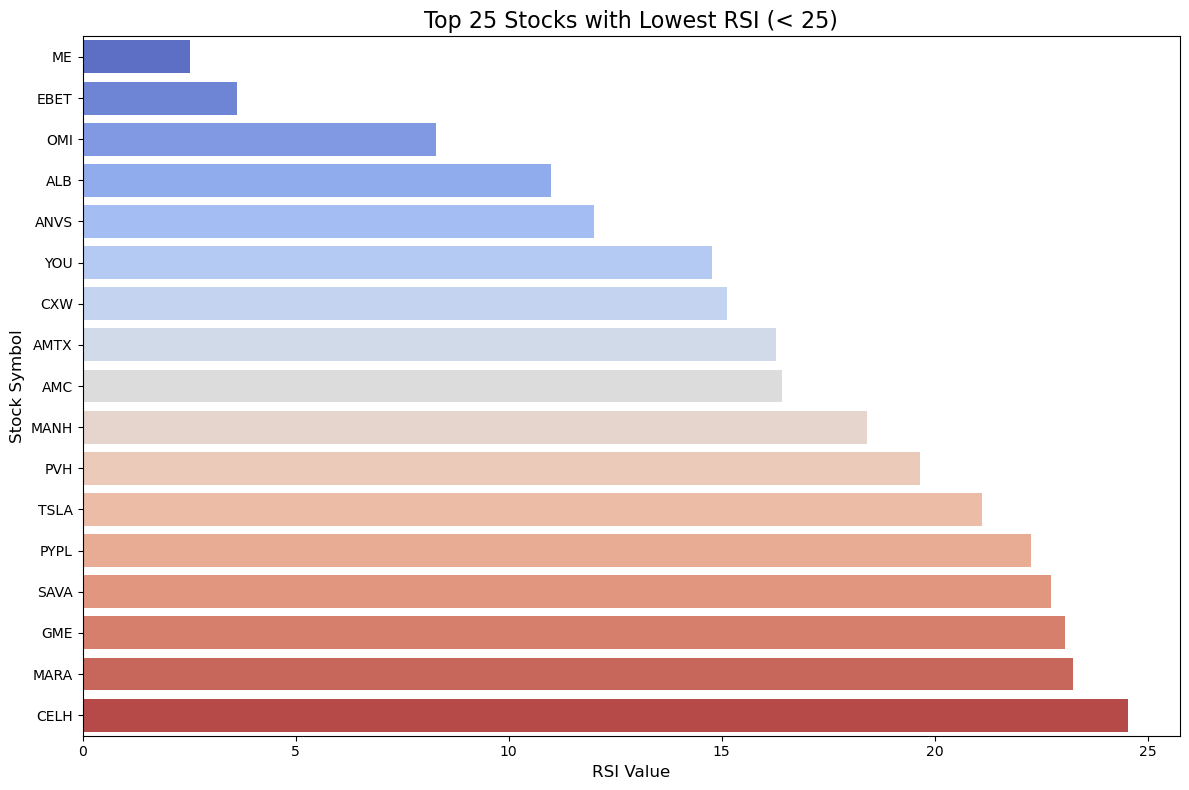

In [195]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Create the bar plot for the stocks with low RSI (<= 25)
plt.figure(figsize=(12, 8))
sns.barplot(x='rsi', y='symbol', data=top_25_low_rsi_pandas, hue='symbol', palette='coolwarm', legend=False)

# Add labels and title
plt.title('Top 25 Stocks with Lowest RSI (< 25)', fontsize=16)
plt.xlabel('RSI Value', fontsize=12)
plt.ylabel('Stock Symbol', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()